# Import libraries
 Import all required libraries for deep learning, data loading, visualization,
 and evaluation. PyTorch is used for building and training the neural network,
 torchvision provides datasets and pre-trained models, and matplotlib/seaborn
 are used for visualizing training performance and confusion matrices.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix

# Device detection
Detect whether a GPU is available for training.
If CUDA is available, the model will use the GPU for faster computation.
Otherwise, the model will run on the CPU.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


# Data preprocessing
 Define data preprocessing and augmentation for the CIFAR-10 dataset.
 Random cropping and horizontal flipping increase dataset diversity
 and help prevent overfitting. Normalization scales pixel values
 to improve training stability.

In [8]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# Load dataset
 Load the CIFAR-10 dataset using torchvision.
 The dataset is automatically downloaded if it does not exist locally.
 DataLoader is used to efficiently load images in batches during training
 and testing.

In [9]:
trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader = DataLoader(testset, batch_size=128, shuffle=False)

classes = trainset.classes

print(classes)

100%|██████████| 170M/170M [00:06<00:00, 28.4MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# Load pretrained model
 Load a pre-trained ResNet-18 model.
 The final fully connected layer is replaced to match the CIFAR-10
 classification task, which contains 10 classes.
 The model is then moved to the selected device.

In [10]:
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 128MB/s]


# Loss function and optimizer
 Define the loss function and optimizer used during training.
 CrossEntropyLoss is commonly used for multi-class classification tasks.
 The Adam optimizer updates the model parameters with adaptive learning
 rates and includes weight decay for regularization.

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Training loop
 Train the model for multiple epochs.
 For each epoch, the model performs forward propagation,
 computes the loss, performs backpropagation, and updates
 model parameters using the optimizer.
 Training and validation loss are recorded to monitor
 learning progress and detect potential overfitting.

In [12]:
num_epochs = 20

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(trainloader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss = val_loss / len(testloader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/20 | Train Loss: 1.0439 | Val Loss: 0.8480
Epoch 2/20 | Train Loss: 0.7472 | Val Loss: 0.7798
Epoch 3/20 | Train Loss: 0.6528 | Val Loss: 0.6937
Epoch 4/20 | Train Loss: 0.6049 | Val Loss: 0.5951
Epoch 5/20 | Train Loss: 0.5654 | Val Loss: 0.5910
Epoch 6/20 | Train Loss: 0.5358 | Val Loss: 0.5694
Epoch 7/20 | Train Loss: 0.5118 | Val Loss: 0.5469
Epoch 8/20 | Train Loss: 0.4963 | Val Loss: 0.5253
Epoch 9/20 | Train Loss: 0.4709 | Val Loss: 0.5750
Epoch 10/20 | Train Loss: 0.4665 | Val Loss: 0.5965
Epoch 11/20 | Train Loss: 0.4477 | Val Loss: 0.5016
Epoch 12/20 | Train Loss: 0.4351 | Val Loss: 0.5085
Epoch 13/20 | Train Loss: 0.4162 | Val Loss: 0.5173
Epoch 14/20 | Train Loss: 0.4119 | Val Loss: 0.5029
Epoch 15/20 | Train Loss: 0.4010 | Val Loss: 0.5019
Epoch 16/20 | Train Loss: 0.3926 | Val Loss: 0.4981
Epoch 17/20 | Train Loss: 0.3781 | Val Loss: 0.4664
Epoch 18/20 | Train Loss: 0.3729 | Val Loss: 0.5074
Epoch 19/20 | Train Loss: 0.3674 | Val Loss: 0.5016
Epoch 20/20 | Train L

#Plot loss curve
 Plot the training loss and validation loss over epochs.
 This visualization helps identify model convergence
 and detect overtraining when validation loss begins
 to increase while training loss continues decreasing.

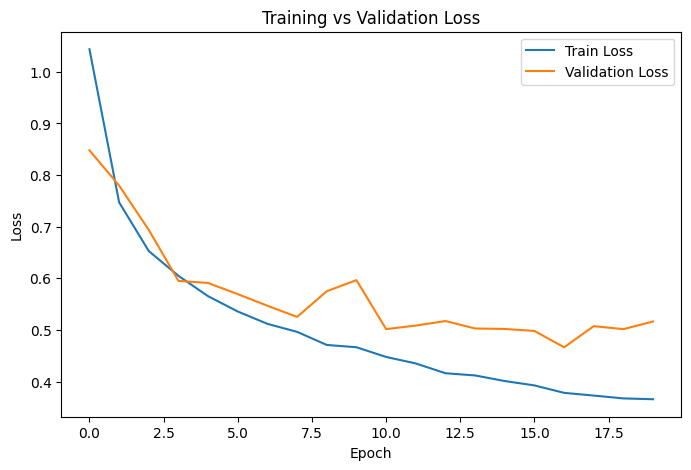

In [13]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

# Overall accuracy
 Evaluate the trained model on the test dataset.
 The overall classification accuracy is calculated
 by comparing predicted labels with the true labels.

In [14]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", correct/total)

Test Accuracy: 0.8262


# Class accuracy
Compute classification accuracy for each CIFAR-10 class.
 This allows analysis of which object categories are
 easier or more difficult for the model to recognize.

In [15]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        for i in range(len(labels)):

            label = labels[i]

            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

for i in range(10):

    print(classes[i], class_correct[i] / class_total[i])

airplane 0.914
automobile 0.939
bird 0.772
cat 0.667
deer 0.762
dog 0.669
frog 0.944
horse 0.885
ship 0.924
truck 0.786


# Confusion matrix
Generate and visualize the confusion matrix.
 The confusion matrix shows how often each class
 is correctly classified or misclassified, which
 helps analyze patterns of model errors.

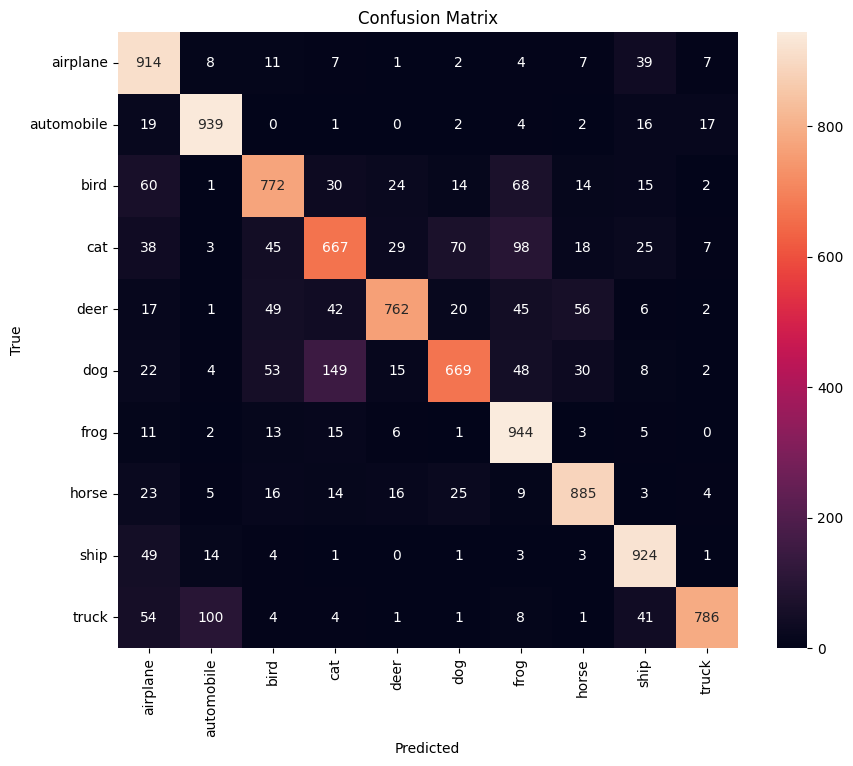

In [16]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()